<a href="https://colab.research.google.com/github/sindhuudivyapriya1998-collab/Diamond-Dynamics-Price-Prediction-and-Market-Segmentation/blob/main/Diamond_project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Diamond Dynamics : Price prediction and market segmentation**

---



## Data Collection



In [1]:
from google.colab import files
uploaded = files.upload()

Saving diamonds.csv to diamonds.csv


In [2]:
import pandas as pd
df_diamond1 = pd.read_csv("/content/diamonds.csv")
df_diamond1

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df_diamond1.shape

(53940, 10)

In [4]:
df_diamond1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
df_diamond1.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


#Data Preprocessing

In [6]:
df_diamond = df_diamond1.drop_duplicates()

In [7]:
df_diamond

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [8]:
df_diamond.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [9]:
(df_diamond[(df_diamond['x'] == 0)|(df_diamond['y'] == 0)|(df_diamond['z'] == 0)])

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [10]:
import numpy as np
df_diamond = df_diamond.copy()
df_diamond[['x','y','z']] = df_diamond[['x','y','z']].replace(0,np.nan)

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

df_diamond[['x','y','z']] = imputer.fit_transform(df_diamond[['x','y','z']])

In [12]:
df_diamond[['x','y','z']].isnull().sum()

,0
x,0
y,0
z,0


#Outliers Handling using IQR

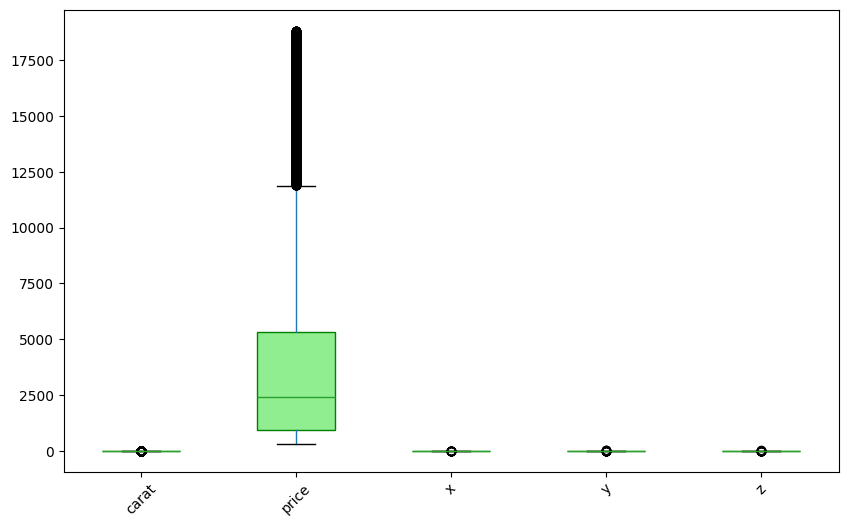

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['carat','price','x','y','z']

plt.figure(figsize=(10,6))
df_diamond[numerical_cols].boxplot(patch_artist=True,boxprops=dict(facecolor='lightgreen',color='green'))
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

In [14]:
for col in numerical_cols:
  Q1 = df_diamond[col].quantile(0.25)
  Q3 = df_diamond[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df_diamond[col] = df_diamond[col].clip(lower,upper)

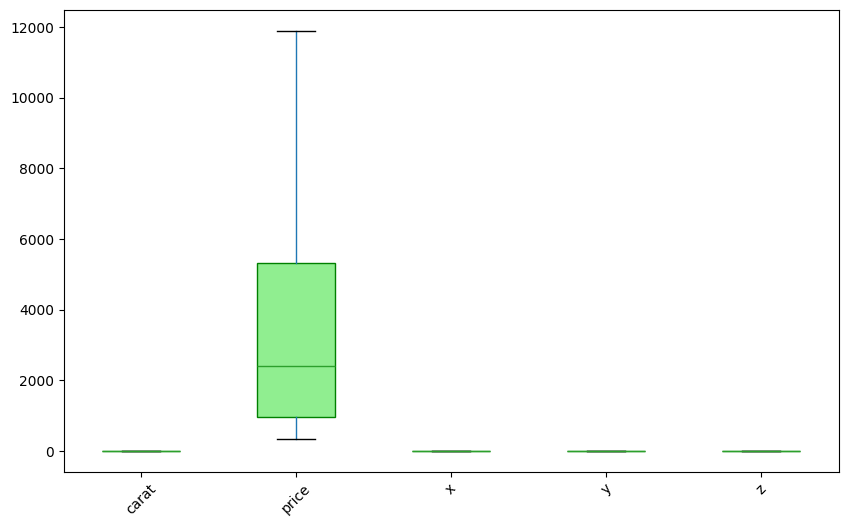

In [15]:
numerical_cols = ['carat','price','x','y','z']

plt.figure(figsize=(10,6))
df_diamond[numerical_cols].boxplot(patch_artist=True,boxprops=dict(facecolor='lightgreen',color='green'))
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

#Skewness Handling using log transformation

In [16]:
skew_cols =['carat','price','x','y','z']
df_diamond[skew_cols].skew()

,0
carat,0.899170
price,1.148606
x,0.392713
y,0.388437
z,0.384730


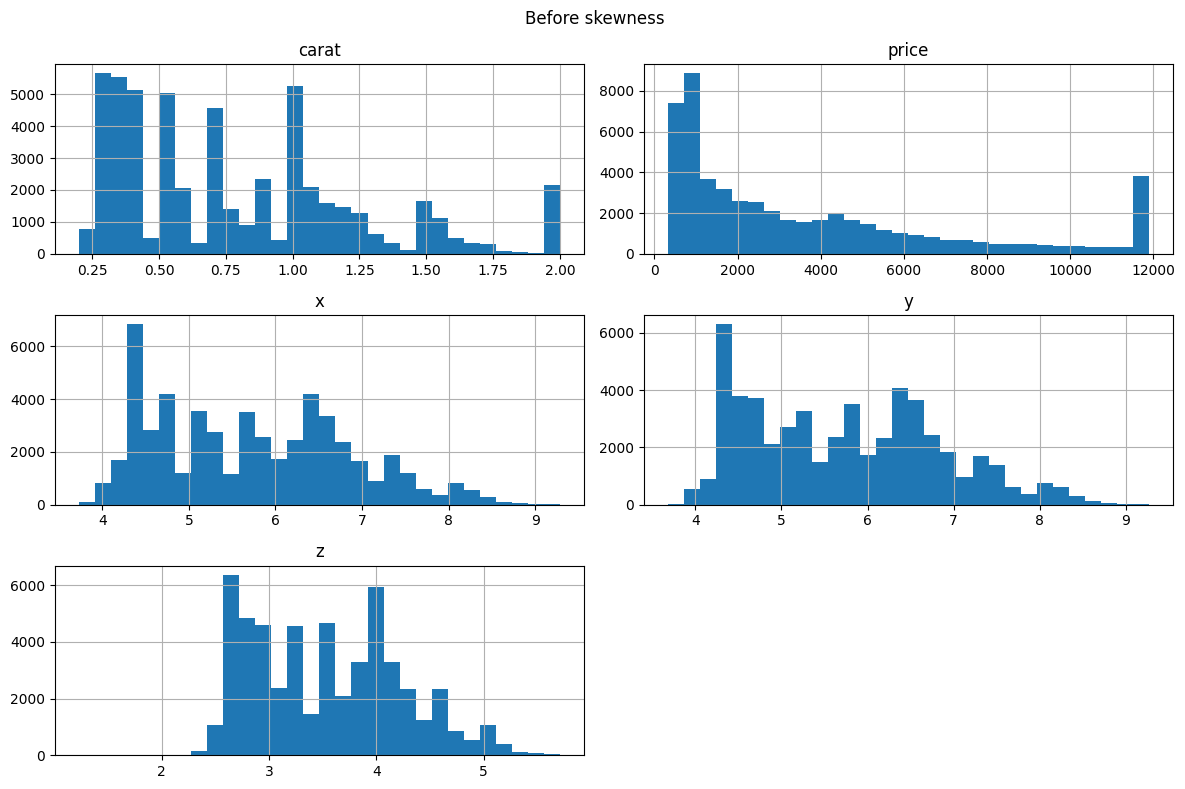

In [17]:
import matplotlib.pyplot as plt

skew_cols = ['carat','price','x','y','z']

df_diamond[skew_cols].hist(figsize=(12,8),bins=30)

plt.suptitle("Before skewness")
plt.tight_layout()
plt.grid(False)
plt.show()



In [18]:
import numpy as np

skew_cols = ['carat','price','x','y','z']

for col in skew_cols:
  df_diamond[col] = np.log1p(df_diamond[col])

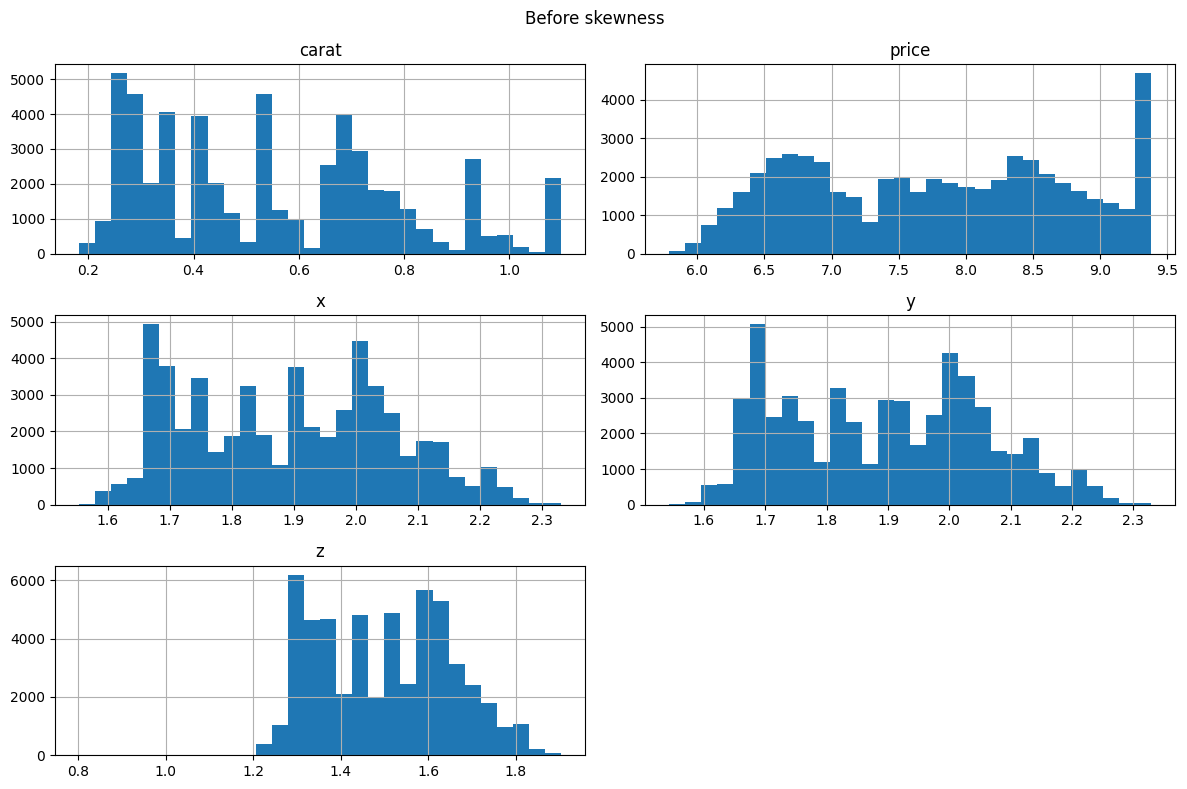

In [19]:
import matplotlib.pyplot as plt

skew_cols = ['carat','price','x','y','z']

df_diamond[skew_cols].hist(figsize=(12,8),bins=30)

plt.suptitle("Before skewness")
plt.tight_layout()
plt.grid(False)
plt.show()



#EDA - Exploratory Data Analysis

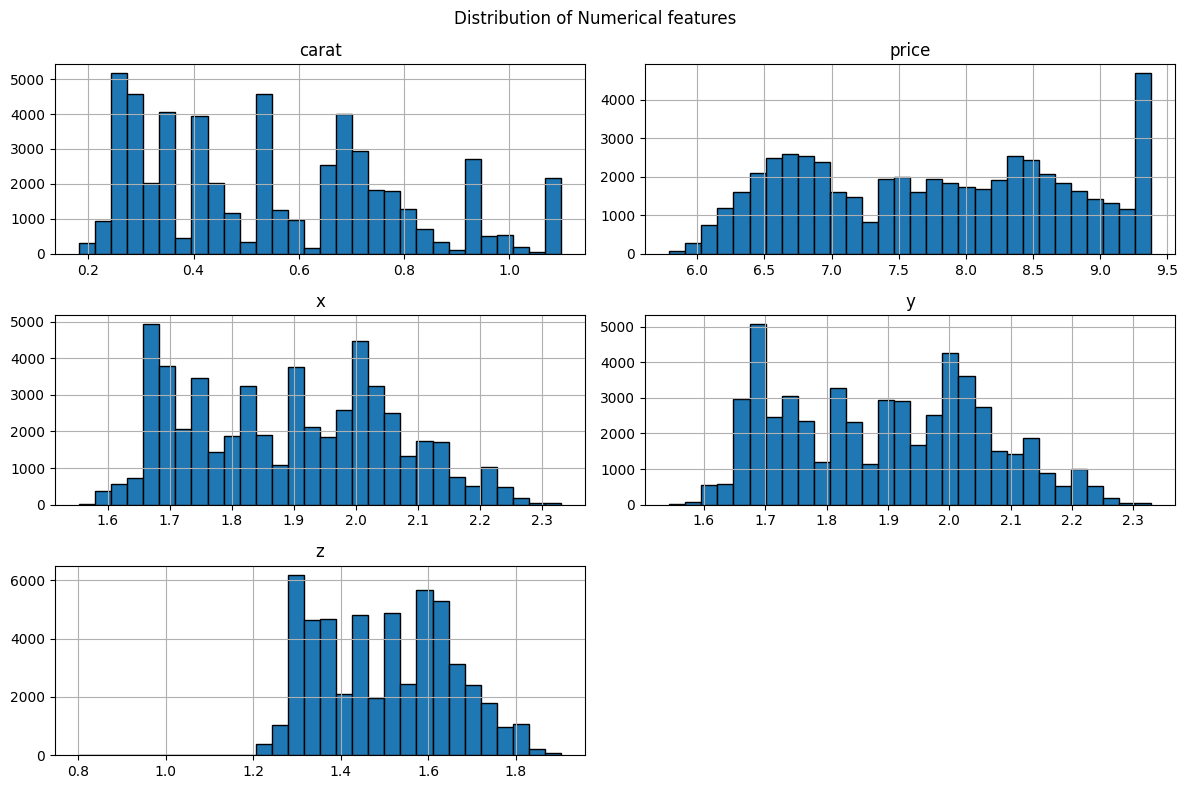

In [20]:
import matplotlib.pyplot as plt

numerical_cols = ['carat','price','x','y','z']

df_diamond[numerical_cols].hist(figsize=(12,8),bins=30, edgecolor ='black')

plt.suptitle("Distribution of Numerical features")
plt.xlabel(col)
plt.ylabel('Frequency')
plt.grid(False)
plt.tight_layout()
plt.show()

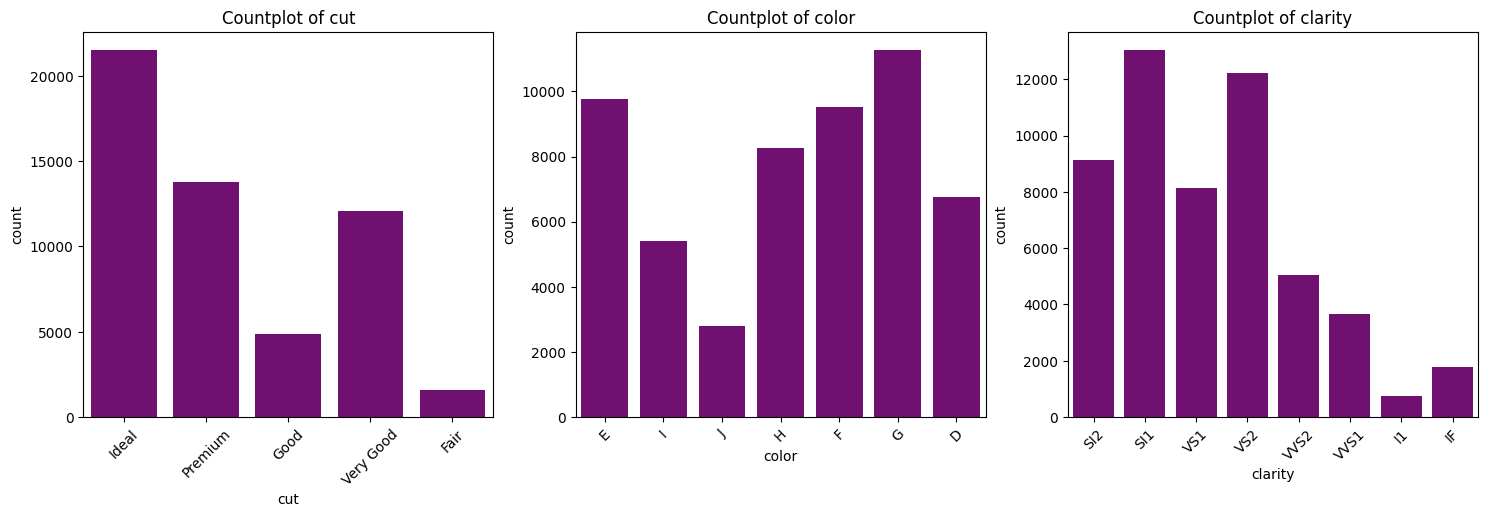

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ['cut','color','clarity']

plt.figure(figsize=(18,5))

for i,col in enumerate(categorical_cols,1):
   plt.subplot(1,3,i)
   sns.countplot(data = df_diamond, x=col, color='purple')
   plt.title(f'Countplot of {col}')
   plt.xticks(rotation=45)

plt.tight_layout
plt.show()

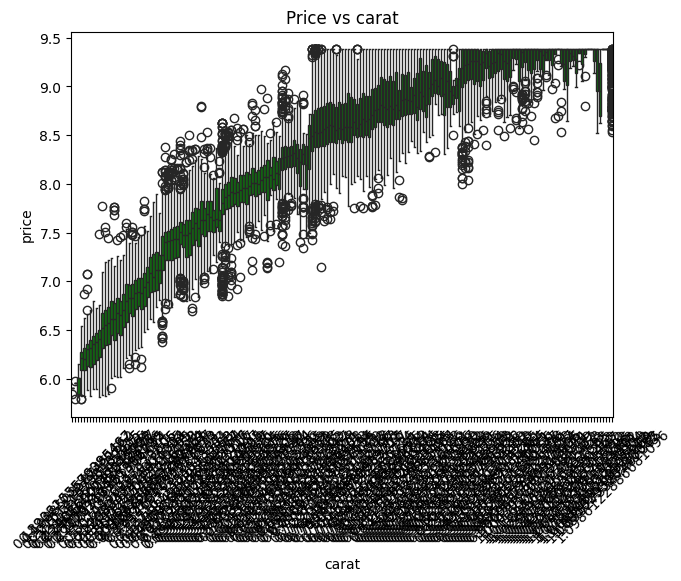

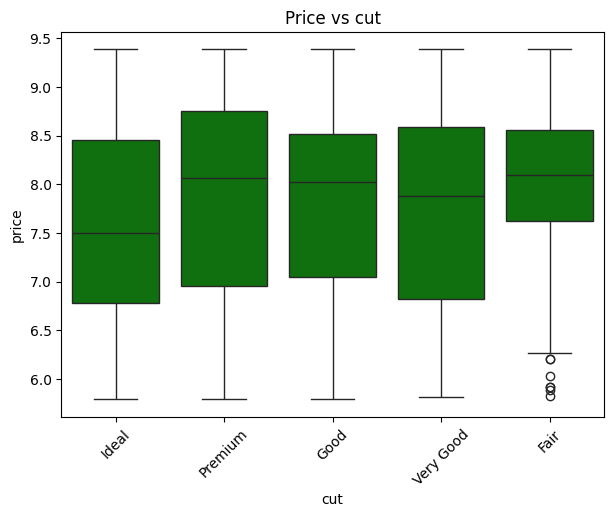

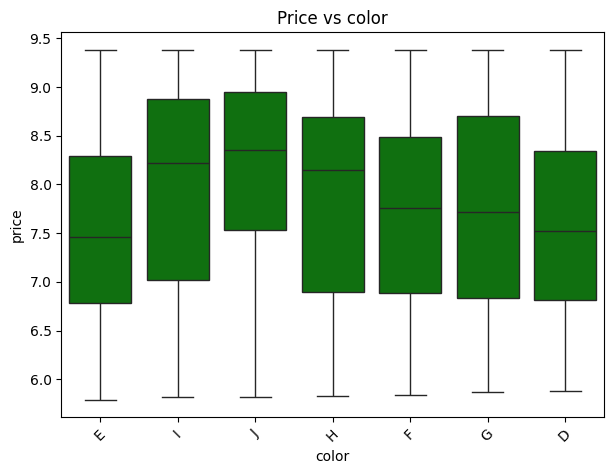

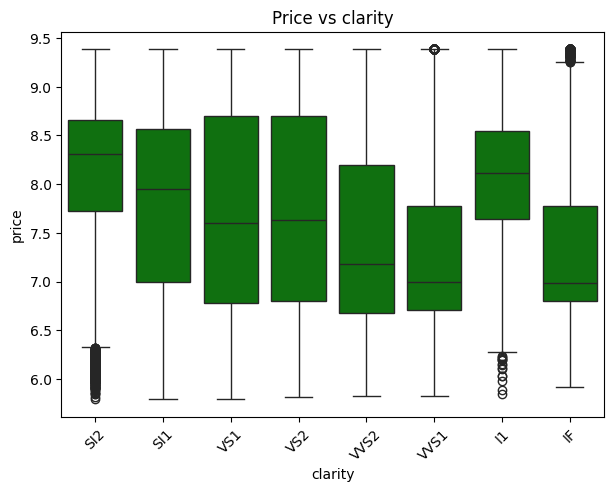

In [22]:
features =['carat','cut','color','clarity']

for col in features:
  plt.figure(figsize=(7,5))
  sns.boxplot(data=df_diamond, x=col, y='price',color='green')
  plt.title(f"Price vs {col}")
  plt.xticks(rotation=45)
  plt.grid(False)
  plt.show()

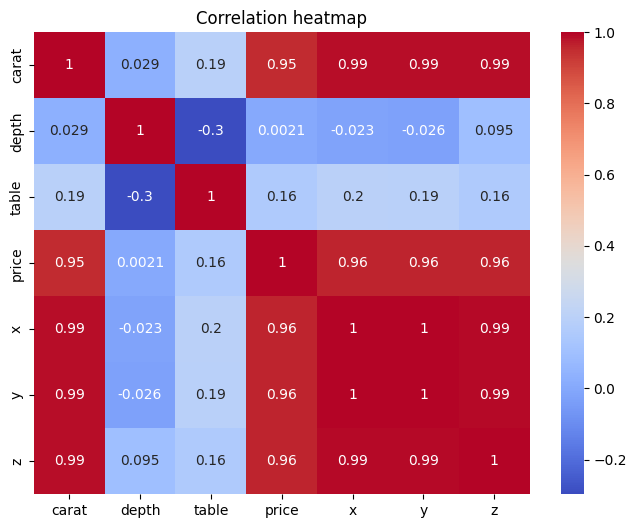

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(df_diamond[['carat','depth','table','price','x','y','z']].corr(),annot =True,cmap='coolwarm')

plt.title("Correlation heatmap")
plt.show()

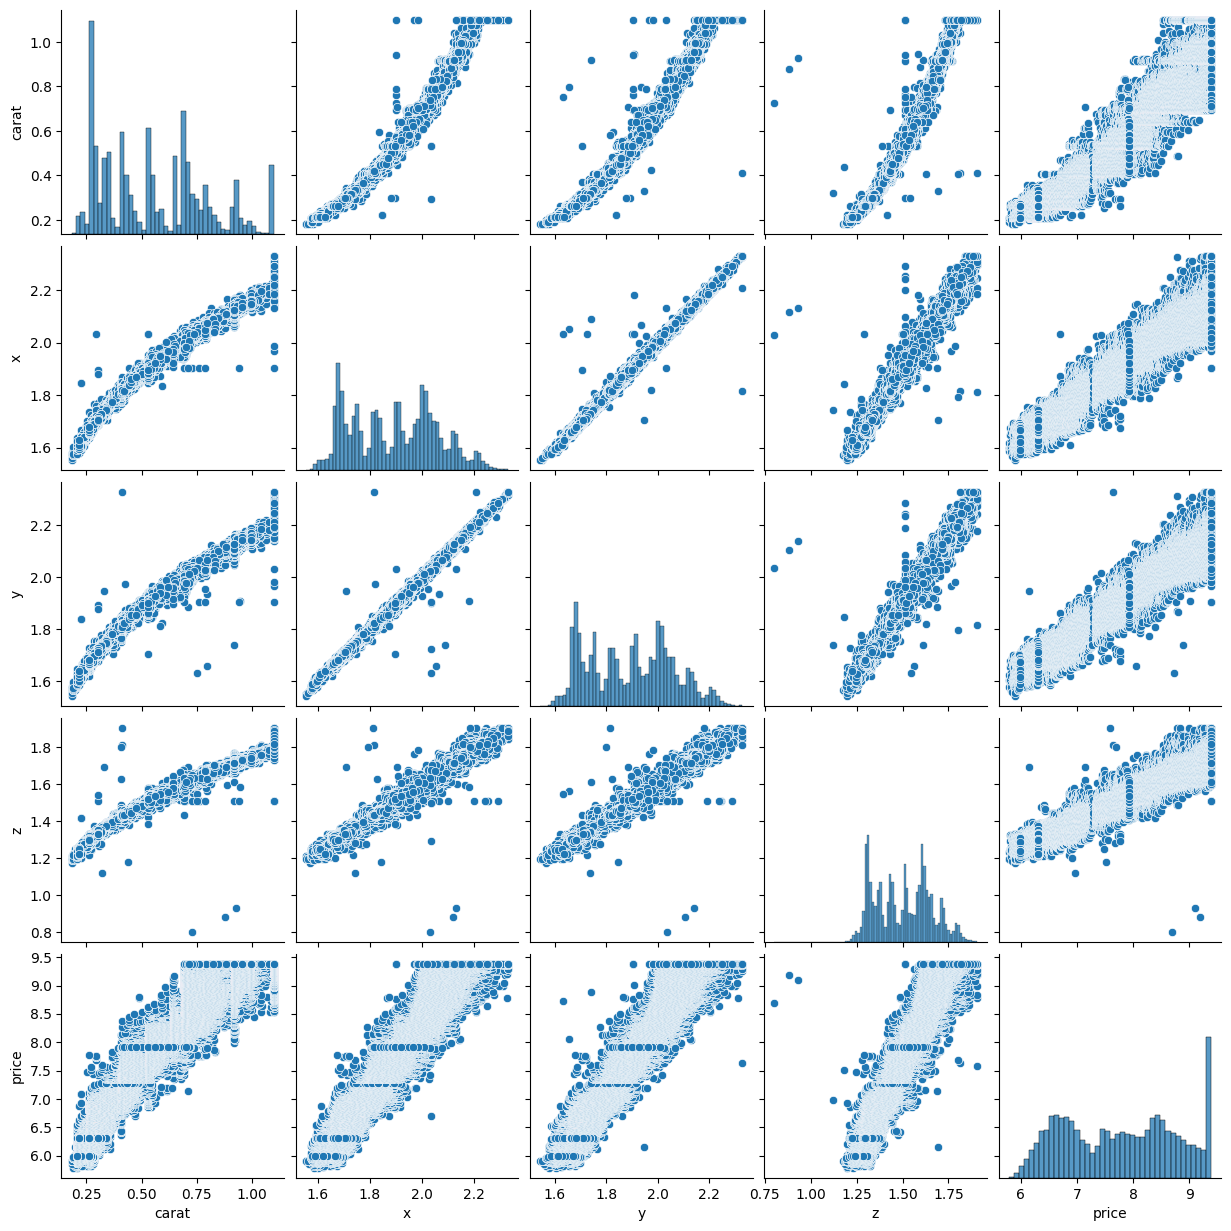

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_diamond[['carat','x','y','z','price']])
plt.show()

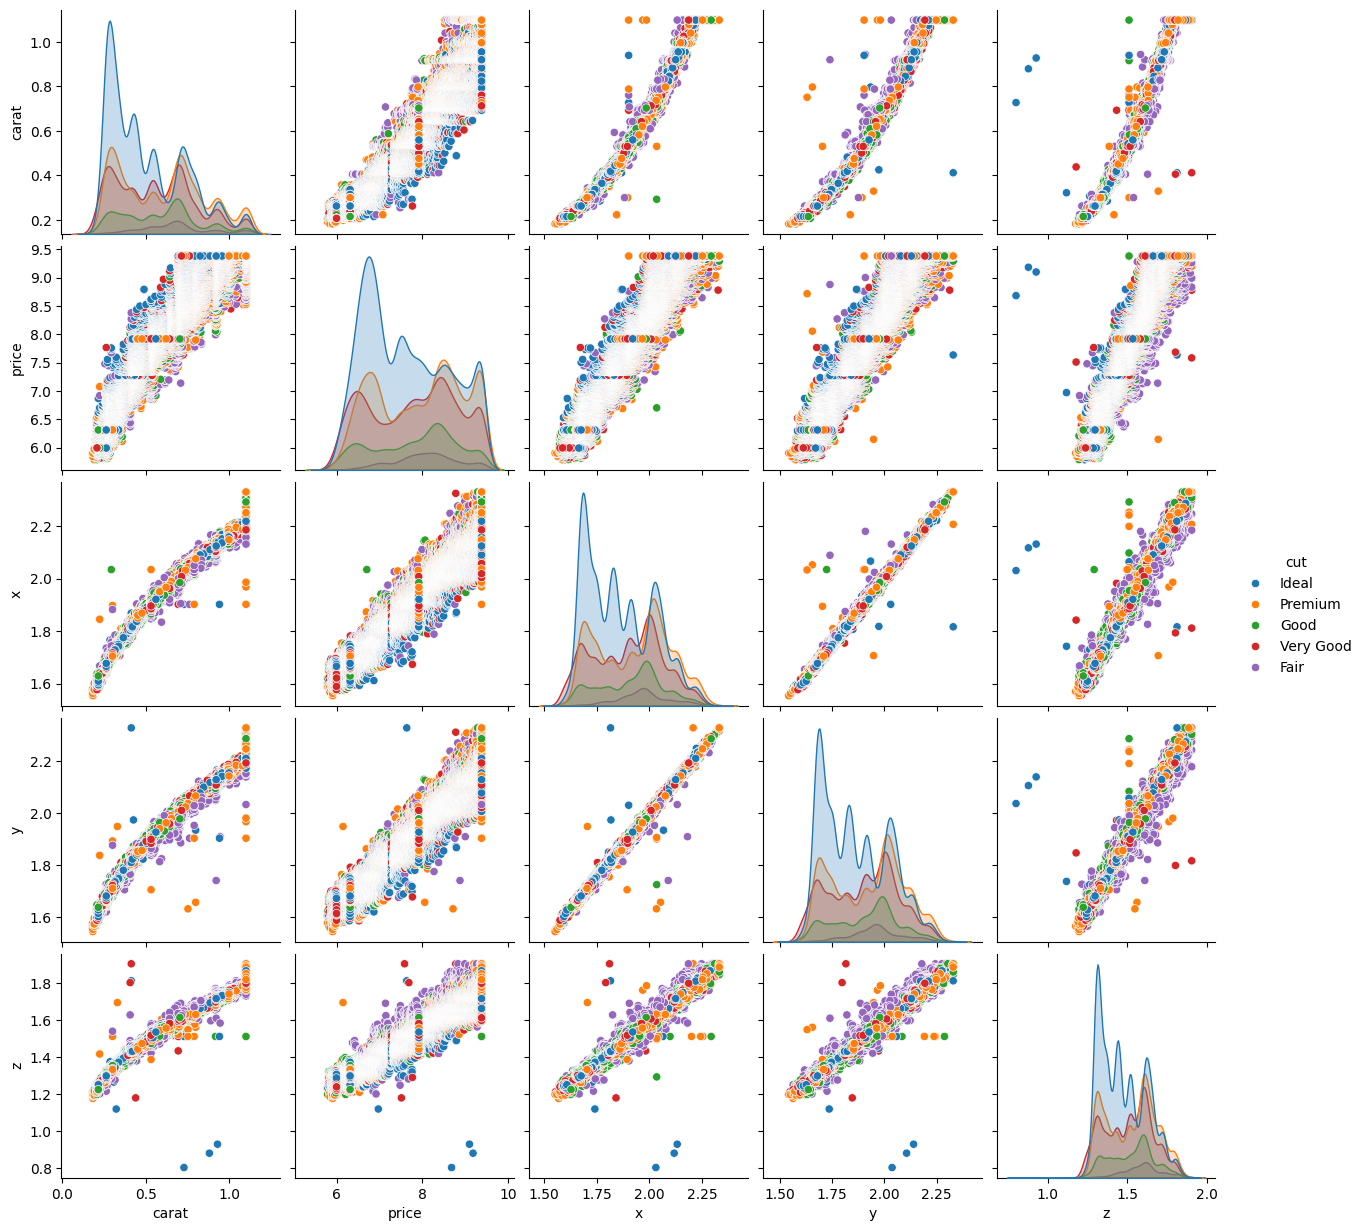

In [25]:
sns.pairplot(df_diamond, vars=['carat','price','x','y','z'], hue ='cut')
plt.show()

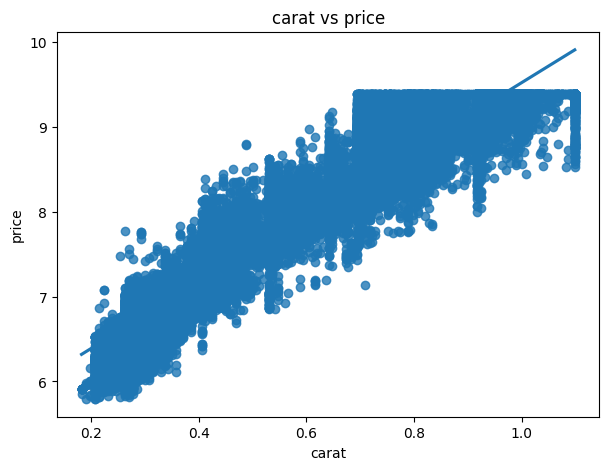

In [26]:
plt.figure(figsize=(7,5))

sns.regplot(data=df_diamond,x='carat',y='price')

plt.title("carat vs price")
plt.show()

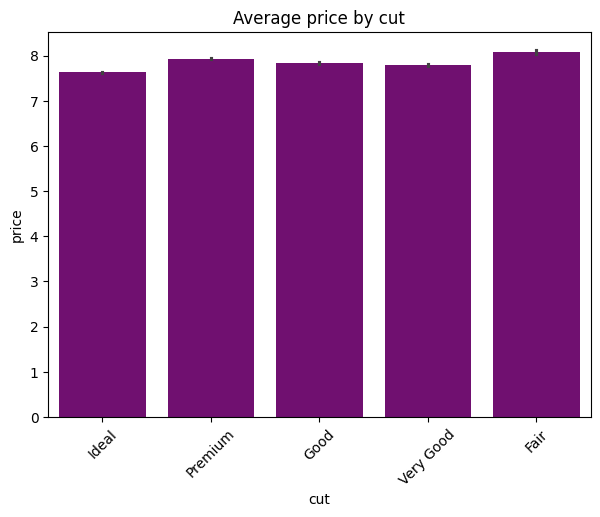

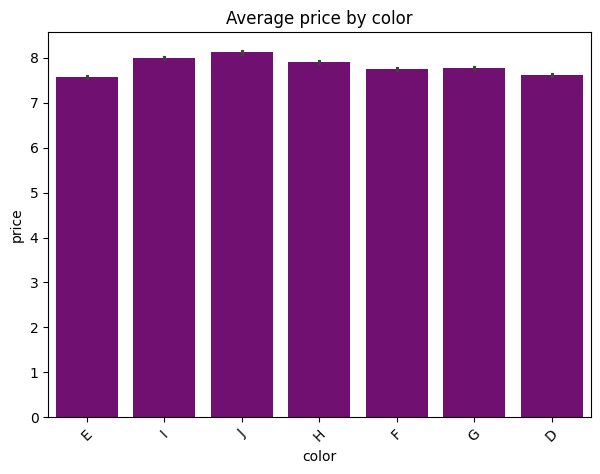

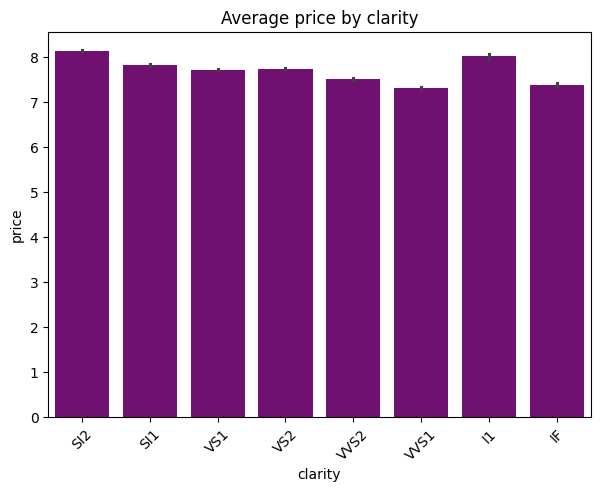

In [27]:
for col in['cut','color','clarity']:
  plt.figure(figsize=(7,5))

  sns.barplot(data=df_diamond,x=col,y='price',color='purple')

  plt.title(f'Average price by {col}')
  plt.xticks(rotation=45)
  plt.show()

#Feature Engineering

In [28]:
usd_to_inr = 87
df_diamond['price_inr'] = df_diamond['price'] * usd_to_inr

In [29]:
df_diamond = df_diamond.drop('price', axis=1)

In [30]:
df_diamond['volume'] = df_diamond['x'] * df_diamond['y'] * df_diamond['z']

In [31]:
df_diamond['price_per_carat'] = df_diamond['price_inr'] / df_diamond['carat']

In [32]:
df_diamond['dimension_ratio'] = (df_diamond['x'] + df_diamond['y'])/ (2 * df_diamond['z'])

In [33]:
def carat_category(carat):
  if carat < 0.5:
     return 'Light'
  elif carat <= 1.5:
     return 'Medium'
  else:
     return 'Heavy'

df_diamond['carat_category'] = df_diamond['carat'].apply(carat_category)

In [34]:
df_diamond['volume_per_carat'] = df_diamond['volume'] / df_diamond['carat']

In [35]:
df_diamond

,carat,cut,color,clarity,depth,table,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category,volume_per_carat
0,0.207014,Ideal,E,SI2,61.5,55.0,1.599388,1.605430,1.232560,503.726535,3.164851,2433.294959,1.300065,Light,15.288087
1,0.190620,Premium,E,SI1,59.8,61.0,1.587192,1.576915,1.196948,503.726535,2.995802,2642.564183,1.321739,Light,15.716065
2,0.207014,Good,E,VS1,56.9,65.0,1.619388,1.623341,1.196948,503.992184,3.146560,2434.578200,1.354582,Light,15.199733
3,0.254642,Premium,I,VS2,62.4,58.0,1.648659,1.654411,1.289233,505.829356,3.516459,1986.431627,1.281022,Light,13.809409
4,0.270027,Good,J,SI2,63.3,58.0,1.675226,1.677097,1.321756,506.088671,3.713493,1874.214111,1.268132,Light,13.752296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,Ideal,D,SI1,60.8,57.0,1.909543,1.911023,1.504077,689.236712,5.488648,1270.894046,1.270069,Medium,10.120602
53936,0.542324,Good,D,SI1,63.1,55.0,1.900614,1.909543,1.528228,689.236712,5.546402,1270.894046,1.246593,Medium,10.227095
53937,0.530628,Very Good,D,SI1,62.8,60.0,1.896119,1.899118,1.517323,689.236712,5.463810,1298.906929,1.250636,Medium,10.296870
53938,0.620576,Premium,H,SI2,61.0,58.0,1.967112,1.962908,1.556037,689.236712,6.008264,1110.639423,1.262830,Medium,9.681746


## Ordinal Encoding

In [36]:
df_diamond.select_dtypes(include='object').columns

Index(['cut', 'color', 'clarity', 'carat_category'], dtype='object')

In [37]:
from sklearn.preprocessing import OrdinalEncoder

cols=['cut','color','clarity','carat_category']
categories =[

    ['Fair','Good','Very Good','Premium','Ideal'],
     ['J','I','H','G','F','E','D'],
      ['I1','SI1','SI2','VS2','VS1','VVS2','VVS1','IF'],
       ['Light','Medium','Heavy']
    ]

encoder = OrdinalEncoder(categories=categories)

df_diamond[[col + '_encoded' for col in cols]] = encoder.fit_transform(df_diamond[cols])

In [38]:
print(df_diamond.select_dtypes(include='object').columns)

Index(['cut', 'color', 'clarity', 'carat_category'], dtype='object')


In [39]:
df_diamond

,carat,cut,color,clarity,depth,table,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category,volume_per_carat,cut_encoded,color_encoded,clarity_encoded,carat_category_encoded
0,0.207014,Ideal,E,SI2,61.5,55.0,1.599388,1.605430,1.232560,503.726535,3.164851,2433.294959,1.300065,Light,15.288087,4.0,5.0,2.0,0.0
1,0.190620,Premium,E,SI1,59.8,61.0,1.587192,1.576915,1.196948,503.726535,2.995802,2642.564183,1.321739,Light,15.716065,3.0,5.0,1.0,0.0
2,0.207014,Good,E,VS1,56.9,65.0,1.619388,1.623341,1.196948,503.992184,3.146560,2434.578200,1.354582,Light,15.199733,1.0,5.0,4.0,0.0
3,0.254642,Premium,I,VS2,62.4,58.0,1.648659,1.654411,1.289233,505.829356,3.516459,1986.431627,1.281022,Light,13.809409,3.0,1.0,3.0,0.0
4,0.270027,Good,J,SI2,63.3,58.0,1.675226,1.677097,1.321756,506.088671,3.713493,1874.214111,1.268132,Light,13.752296,1.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,Ideal,D,SI1,60.8,57.0,1.909543,1.911023,1.504077,689.236712,5.488648,1270.894046,1.270069,Medium,10.120602,4.0,6.0,1.0,1.0
53936,0.542324,Good,D,SI1,63.1,55.0,1.900614,1.909543,1.528228,689.236712,5.546402,1270.894046,1.246593,Medium,10.227095,1.0,6.0,1.0,1.0
53937,0.530628,Very Good,D,SI1,62.8,60.0,1.896119,1.899118,1.517323,689.236712,5.463810,1298.906929,1.250636,Medium,10.296870,2.0,6.0,1.0,1.0
53938,0.620576,Premium,H,SI2,61.0,58.0,1.967112,1.962908,1.556037,689.236712,6.008264,1110.639423,1.262830,Medium,9.681746,3.0,2.0,2.0,1.0


In [40]:
df_diamond.drop(columns=['cut','color','clarity','carat_category'],inplace=True)

In [41]:
df_diamond.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   carat                   53794 non-null  float64
 1   depth                   53794 non-null  float64
 2   table                   53794 non-null  float64
 3   x                       53794 non-null  float64
 4   y                       53794 non-null  float64
 5   z                       53794 non-null  float64
 6   price_inr               53794 non-null  float64
 7   volume                  53794 non-null  float64
 8   price_per_carat         53794 non-null  float64
 9   dimension_ratio         53794 non-null  float64
 10  volume_per_carat        53794 non-null  float64
 11  cut_encoded             53794 non-null  float64
 12  color_encoded           53794 non-null  float64
 13  clarity_encoded         53794 non-null  float64
 14  carat_category_encoded  53794 non-null  flo

#Feature Selection

### Feature importance using Random forest

In [42]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = df_diamond.drop(['price_inr','price_per_carat'],axis=1)
y = df_diamond['price_inr']

rf = RandomForestRegressor(random_state=42)

rf.fit(X,y)

importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

print(importance)


                   Feature  Importance
4                        y    0.754834
6                   volume    0.154372
11         clarity_encoded    0.030429
0                    carat    0.027867
10           color_encoded    0.014024
3                        x    0.012372
8         volume_per_carat    0.002101
9              cut_encoded    0.001044
7          dimension_ratio    0.000894
5                        z    0.000747
2                    table    0.000722
1                    depth    0.000575
12  carat_category_encoded    0.000017


#Model Building

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "KNeighbors Regressor": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor()
}
# Train and evaluate models
results = []

for name, model in models.items():
   if name == "KNeighbors Regressor":
     model.fit(X_train_scaled, y_train)  # Train the model
     y_pred = model.predict(X_test_scaled)
   else:
     model.fit(X_train,y_train)
     y_pred = model.predict(X_test)

    # Compute evaluation metrics
   mae = mean_absolute_error(y_test, y_pred)
   mse = mean_squared_error(y_test, y_pred)
   rmse = np.sqrt(mse)
   r2 = r2_score(y_test, y_pred)

   results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
   })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,11.144424,196.675126,14.024091,0.972774
1,Decision Tree Regressor,6.847366,109.076362,10.443963,0.984901
2,Random Forest Regressor,5.186486,59.105883,7.688035,0.991818
3,KNeighbors Regressor,7.899835,119.144710,10.915343,0.983507
4,XGBoost Regressor,5.215078,54.812320,7.403534,0.992412


In [46]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Define the model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)

# Perform Cross-Validation
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')

# Print all 5 scores
print("R2 cv Scores:" ,cv_scores)
print("mean cv r2:",cv_scores.mean())
print("std cv r2:", cv_scores.std())

R2 cv Scores: [0.99253424 0.99261567 0.99312242 0.99261316 0.99217908]
mean cv r2: 0.9926129139070055
std cv r2: 0.0003013336987483118


In [47]:
!pip install tensorflow

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import numpy as np

ann_model = Sequential([Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),                        # input layer
    Dense(32, activation='relu'), # hidden layer 1
    Dense(16, activation='relu'),  # hidden layer 2
    Dense(1) # output layer
])

# Compile Model

ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)


history = ann_model.fit(
    X_train_scaled, y_train_scaled, validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_pred_scaled = ann_model.predict(X_test_scaled)

y_pred_ann = y_scaler.inverse_transform(y_pred_scaled).flatten()

# 6. Evaluate on Test Data
mse_ann = mean_squared_error(y_test, y_pred_ann)
mae_ann = mean_absolute_error(y_test,y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test,y_pred_ann)

ann_result = pd.DataFrame([{"Model": "ANN",
        "MAE": mae_ann,
        "MSE": mse_ann,
        "RMSE": np.sqrt(mse_ann),
        "R2 Score":r2_ann
}])

results_df = pd.concat([results_df,ann_result],ignore_index=True)

results_df

Epoch 1/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0376 - mae: 0.1379 - val_loss: 0.0261 - val_mae: 0.1176
Epoch 2/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0221 - mae: 0.1120 - val_loss: 0.0206 - val_mae: 0.1105
Epoch 3/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0179 - mae: 0.1023 - val_loss: 0.0170 - val_mae: 0.0988
Epoch 4/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0140 - mae: 0.0907 - val_loss: 0.0147 - val_mae: 0.0930
Epoch 5/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0126 - mae: 0.0859 - val_loss: 0.0129 - val_mae: 0.0871
Epoch 6/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0118 - mae: 0.0830 - val_loss: 0.0114 - val_mae: 0.0814
Epoch 7/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0110 - mae: 0.0802 - val_loss: 0.0116 - val_mae: 0.0810
Epoch 8/100
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0109 - mae: 0.0791 - val_loss: 0.0108 - val_mae: 0.0767
Epoch 9/100
1076/1076 ━━━━━━━━━

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,11.144424,196.675126,14.024091,0.972774
1,Decision Tree Regressor,6.847366,109.076362,10.443963,0.984901
2,Random Forest Regressor,5.186486,59.105883,7.688035,0.991818
3,KNeighbors Regressor,7.899835,119.144710,10.915343,0.983507
4,XGBoost Regressor,5.215078,54.812320,7.403534,0.992412
5,ANN,5.603507,61.392615,7.835344,0.991501


#Save the XGB model

In [50]:
import joblib
xgb_model.fit(X,y)

joblib.dump(xgb_model,"xgb_Best_model.pkl")

['xgb_Best_model.pkl']

#Save the scaler

In [51]:
import joblib
joblib.dump(scaler,"X_scaler.pkl")
joblib.dump(y_scaler,"y_scaler.pkl")

['y_scaler.pkl']

#Load Model

In [52]:
print(scaler.n_features_in_)
print(scaler.feature_names_in_)

13
['carat' 'depth' 'table' 'x' 'y' 'z' 'volume' 'dimension_ratio'
 'volume_per_carat' 'cut_encoded' 'color_encoded' 'clarity_encoded'
 'carat_category_encoded']


In [53]:
import joblib

xgb_model = joblib.load("xgb_Best_model.pkl")

X_scaler = joblib.load("X_scaler.pkl")
y_scaler = joblib.load("y_scaler.pkl")

In [54]:
y_pred_scaled = xgb_model.predict(X_test_scaled)


#Clustering

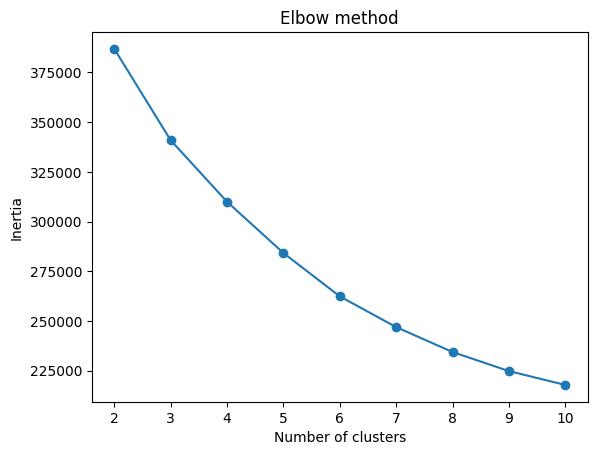

In [55]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_cluster = df_diamond.drop('price_inr',axis=1)

Scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

inertia=[]

for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(range(2,11),inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

In [56]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

df_diamond['cluster'] = kmeans.fit_predict(X_scaled)

In [57]:
reverse_cut = {
    1: 'Fair',
    2: 'Good',
    3: 'Very Good',
    4: 'Premium',
    5: 'Ideal'
}

df_diamond['cut_label'] = df_diamond['cut_encoded'].map(reverse_cut)


cut_distribution_percent = pd.crosstab( df_diamond['cluster'],df_diamond['cut_label'], normalize='index') * 100

cut_distribution_percent.round(2)



cut_label,Fair,Good,Premium,Very Good
cluster,,,,
0,12.70,27.18,32.64,27.48
1,10.29,22.29,45.93,21.49
2,8.72,22.20,33.34,35.74
3,4.70,19.08,54.07,22.15


In [58]:
print(df_diamond['cluster'].value_counts())

cluster
0    18903
3    13721
1    11166
2    10004
Name: count, dtype: int64


In [59]:
cluster_summary = df_diamond.groupby('cluster')[['price_inr','carat']].mean().round(2)

cluster_summary = cluster_summary.join(cut_distribution_percent.round(2))

cluster_summary

,price_inr,carat,Fair,Good,Premium,Very Good
cluster,,,,,,
0,722.25,0.65,12.70,27.18,32.64,27.48
1,624.34,0.40,10.29,22.29,45.93,21.49
2,787.33,0.92,8.72,22.20,33.34,35.74
3,574.27,0.28,4.70,19.08,54.07,22.15


In [60]:
cluster_names ={ 0: "Mid-range Balanced Diamonds",
                1: "Premium Small Diamonds",
                 2: "Premium Heavy Diamonds",
                 3: "Affordable Small Diamonds"
                 }

df_diamond['cluster_name'] = df_diamond['cluster'].map(cluster_names)

In [61]:
import pickle

with open('cluster_model.pkl','wb') as file:
  pickle.dump(kmeans, file)

with open('cluster_scaler.pkl','wb') as file:
  pickle.dump(scaler, file)

In [62]:
df_diamond

,carat,depth,table,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,volume_per_carat,cut_encoded,color_encoded,clarity_encoded,carat_category_encoded,cluster,cut_label,cluster_name
0,0.207014,61.5,55.0,1.599388,1.605430,1.232560,503.726535,3.164851,2433.294959,1.300065,15.288087,4.0,5.0,2.0,0.0,3,Premium,Affordable Small Diamonds
1,0.190620,59.8,61.0,1.587192,1.576915,1.196948,503.726535,2.995802,2642.564183,1.321739,15.716065,3.0,5.0,1.0,0.0,3,Very Good,Affordable Small Diamonds
2,0.207014,56.9,65.0,1.619388,1.623341,1.196948,503.992184,3.146560,2434.578200,1.354582,15.199733,1.0,5.0,4.0,0.0,3,Fair,Affordable Small Diamonds
3,0.254642,62.4,58.0,1.648659,1.654411,1.289233,505.829356,3.516459,1986.431627,1.281022,13.809409,3.0,1.0,3.0,0.0,3,Very Good,Affordable Small Diamonds
4,0.270027,63.3,58.0,1.675226,1.677097,1.321756,506.088671,3.713493,1874.214111,1.268132,13.752296,1.0,0.0,2.0,0.0,3,Fair,Affordable Small Diamonds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,60.8,57.0,1.909543,1.911023,1.504077,689.236712,5.488648,1270.894046,1.270069,10.120602,4.0,6.0,1.0,1.0,0,Premium,Mid-range Balanced Diamonds
53936,0.542324,63.1,55.0,1.900614,1.909543,1.528228,689.236712,5.546402,1270.894046,1.246593,10.227095,1.0,6.0,1.0,1.0,0,Fair,Mid-range Balanced Diamonds
53937,0.530628,62.8,60.0,1.896119,1.899118,1.517323,689.236712,5.463810,1298.906929,1.250636,10.296870,2.0,6.0,1.0,1.0,0,Good,Mid-range Balanced Diamonds
53938,0.620576,61.0,58.0,1.967112,1.962908,1.556037,689.236712,6.008264,1110.639423,1.262830,9.681746,3.0,2.0,2.0,1.0,0,Very Good,Mid-range Balanced Diamonds


In [63]:
print(X.columns.tolist())

['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'dimension_ratio', 'volume_per_carat', 'cut_encoded', 'color_encoded', 'clarity_encoded', 'carat_category_encoded']


In [64]:
print(X.shape)

(53794, 13)


#Streamlit Application

In [65]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 101.6 MB/s eta 0:00:00
--2026-08-11 02:05:45--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64 [following]
--2026-08-11 02:05:46--  https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/3812f7fa-ce13-4147-a9fb-197be83d49fa?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-11T02%3A45%3A05Z&rscd=attachment%3B+filename%3

In [86]:
%%writefile Diamond_app.py

import streamlit as st
import numpy as np
import pandas as pd
import pickle
import joblib
from tensorflow.keras.models import load_model

xgb_model = joblib.load("xgb_Best_model.pkl")

with open("X_scaler.pkl","rb") as f:
  X_scaler = joblib.load(f)

with open("y_scaler.pkl","rb") as f:
  y_scaler = joblib.load(f)

with open("cluster_model.pkl","rb") as f:
  kmeans = pickle.load(f)

with open("cluster_scaler.pkl","rb") as f:
  cluster_scaler = pickle.load(f)


st.set_page_config(
    page_title="💎Diamond Analysis",
    page_icon ="",
    layout ="wide"
)

st.title(" 💎Diamond Price Prediction & Market Segmentation")

module = st.sidebar.selectbox("Select Module",
                              ["Price Prediction","Clustering"]
)

carat =st.number_input("Carat", min_value=0.1, value=1.0)
depth =st.number_input("Depth", min_value=0.1,value=61.5)
table =st.number_input("Table", min_value=0.1, value=57.0)
x = st.number_input("X", min_value=0.1, value=5.0)
y = st.number_input("Y", min_value=0.1, value=5.0)
z = st.number_input("Z", min_value=0.1, value=3.0)

cut = st.selectbox("cut",["Fair","Good","Very Good","Premium","Ideal"]
                      )
color = st.selectbox("color",["D","E","F","G","H","I","J"]
                        )
clarity = st.selectbox("clarity",["I1","SI1","SI2","VS2","VS1","VVS2","VVS1","IF"]
                          )

cut_mapping = { "Fair": 1,
               "Good": 2,
                "Very Good": 3,
                "Premium": 4,
                "Ideal": 5
}

color_mapping = { "D": 7,
                 "E":6,
                  "F":5,
                  "G":4,
                  "H":3,
                  "I":2,
                  "J":1
                  }
clarity_mapping ={ "I1": 1,
                  "SI2": 2,
                   "SI1": 3,
                   "VS2": 4,
                   "VS1": 5,
                   "VVS2":6,
                   "VVS1":7,
                   "IF":8
                   }

cut_encoded = cut_mapping[cut]
color_encoded = color_mapping[color]
clarity_encoded= clarity_mapping[clarity]

if module == "Price Prediction":

   st.header("💰Price Prediction")

   if st.button("Predict Price"):
      volume = x * y * z

      price_per_carat = 0
      dimension_ratio = x/y if y != 0 else 0
      volume_per_carat = volume/carat if carat != 0 else 0

      if carat < 0.5:
           carat_category_encoded = 1
      elif carat < 1.0:
            carat_category_encoded = 2
      else:
            carat_category_encoded = 3

      input_data= pd.DataFrame({
          "carat":[carat],
          "depth":[depth],
          "table":[table],
          "x":[x],
          "y":[y],
          "z":[z],
          "volume":[volume],
          "dimension_ratio":[dimension_ratio],
          "volume_per_carat":[volume_per_carat],
          "cut_encoded":[cut_encoded],
          "color_encoded":[color_encoded],
          "clarity_encoded":[clarity_encoded],
          "carat_category_encoded":[carat_category_encoded]
      })

      input_scaled = X_scaler.transform(input_data)

      prediction = xgb_model.predict(input_scaled)

      predicted_price = prediction[0]

      st.success(f"Predicted Price: ₹{predicted_price:,.2f}")

elif module == "Clustering":

      st.header("📉Market Segment Prediction")

      if st.button("Predict Cluster"):
         volume= x * y * z

         price_per_carat = 0
         dimension_ratio = x/y if y != 0 else 0
         volume_per_carat = volume/carat if carat != 0 else 0

         if carat < 0.5:
           carat_category_encoded = 1
         elif carat < 1.0:
            carat_category_encoded = 2
         else:
            carat_category_encoded = 3

         cluster_input = pd.DataFrame ({
             "carat" : [carat],
             "depth":[depth],
             "table":[table],
             "x":[x],
             "y":[y],
             "z":[z],
             "volume":[volume],
             "price_per_carat":[price_per_carat],
             "dimension_ratio":[dimension_ratio],
             "volume_per_carat":[volume_per_carat],
             "cut_encoded":[cut_encoded],
             "color_encoded":[color_encoded],
             "clarity_encoded":[clarity_encoded],
             "carat_category_encoded":[carat_category_encoded]
        })

         cluster_scaler = cluster_scaler.transform(cluster_input)
         cluster_prediction = kmeans.predict(cluster_scaler)[0]

         cluster_names = {
                 0: "Mid-range Balanced Diamonds",
                 1: "Premium Small Diamonds",
                 2: "Premium Heavy Diamonds",
                 3: "Affordable Small Diamonds"
         }

         cluster_name = cluster_names[cluster_prediction]

         st.success(f"Cluster:{cluster_prediction}")
         st.success(f"Market Segment: {cluster_name}")






Overwriting Diamond_app.py


In [74]:
print(X_cluster.columns.tolist())

['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'price_per_carat', 'dimension_ratio', 'volume_per_carat', 'cut_encoded', 'color_encoded', 'clarity_encoded', 'carat_category_encoded']


In [76]:
!streamlit run /content/Diamond_app.py &>/content/logs.txt &

In [77]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://parental-eos-vault-proceeding.trycloudflare.com
